# Simple Linear Regression

## Project Overview

This project demonstrates how to build a Simple Linear Regression model using Python and Scikit-learn. The workflow includes data loading, exploration, model training, prediction, evaluation, and visualization.

## Import Libraries


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

## Load Dataset

In [21]:
Before_df=pd.read_csv("/content/Simple linear regression.csv")
df=pd.read_csv("/content/Simple linear regression.csv")
print("Data set uploaded")

Data set uploaded


# Data Exploration

In [22]:
df.head()

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83


In [23]:
df.shape

(100, 2)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SAT     100 non-null    int64  
 1   GPA     100 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


In [25]:
# No null values in dataset

# Statistical Analysis

In [26]:
df.describe()

,SAT,GPA
count,100.000000,100.000000
mean,1850.760000,3.360500
std,101.566331,0.258845
min,1634.000000,2.400000
25%,1776.500000,3.270000
50%,1850.000000,3.410000
75%,1934.000000,3.520000
max,2050.000000,3.810000


In [27]:
# convert Decimal values of GPA into nearest lower value
Before_df['GPA']=np.floor(df['GPA']).astype(int)

In [28]:
Before_df.head()

,SAT,GPA
0,1714,2
1,1664,2
2,1760,2
3,1685,2
4,1693,2


# Data Preprocessing

In [29]:
# independent variable
X=df['SAT']
# dependent variable
y=df['GPA']

In [30]:
X = X.values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")

Data split into training and testing sets.


# Model Training

In [31]:
from sklearn.linear_model import LinearRegression
# Create a Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [32]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Predictions generated for training and testing datasets.")

Predictions generated for training and testing datasets.


# Model Evaluation

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Evaluate on training data
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

print("Training Data Evaluation:")
print(f"  MAE: {mae_train:.4f}")
print(f"  MSE: {mse_train:.4f}")
print(f"  RMSE: {rmse_train:.4f}")
print(f"  R2 Score: {r2_train:.4f}")

Training Data Evaluation:
  MAE: 0.1445
  MSE: 0.0367
  RMSE: 0.1917
  R2 Score: 0.3509


In [34]:
# Evaluate on testing data
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print("Testing Data Evaluation:")
print(f"  MAE: {mae_test:.4f}")
print(f"  MSE: {mse_test:.4f}")
print(f"  RMSE: {rmse_test:.4f}")
print(f"  R2 Score: {r2_test:.4f}")

Testing Data Evaluation:
  MAE: 0.1785
  MSE: 0.0607
  RMSE: 0.2465
  R2 Score: 0.4169


In [35]:
model.coef_

array([0.00148288])

In [36]:
model.intercept_

np.float64(0.6222219309814476)

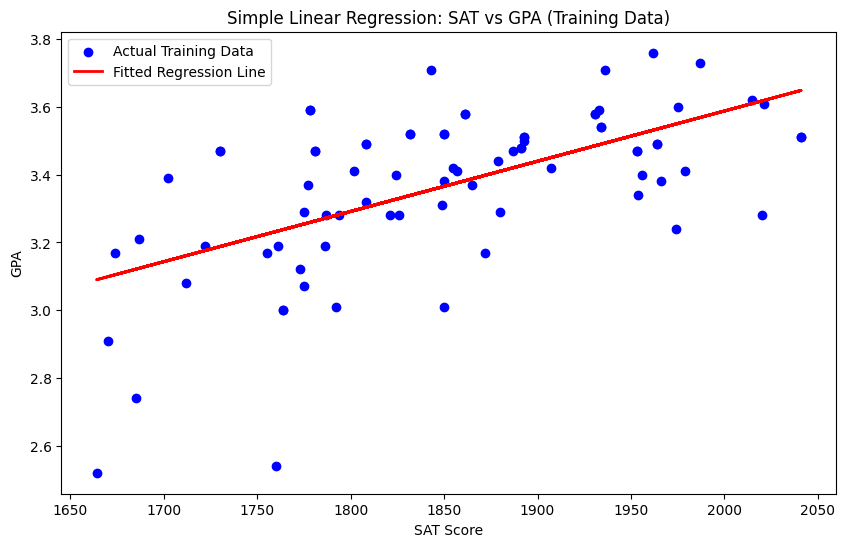

In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Actual Training Data')
plt.plot(X_train, y_train_pred, color='red', linewidth=2, label='Fitted Regression Line')
plt.title('Simple Linear Regression: SAT vs GPA (Training Data)')
plt.xlabel('SAT Score')
plt.ylabel('GPA')
plt.legend()
plt.show()